<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/Evaluating_LLMs_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Évaluation des LLM pour la Synthèse de Texte

## Resources

Bienvenue dans ce notebook d'évaluation des modèles de langage (LLM) pour la synthèse de texte. Ce document vous guidera à travers les étapes essentielles pour évaluer et comparer les performances de différents LLM en matière de résumé.

Ce que vous allez apprendre et mettre en œuvre :

- **Installation et Configuration :** Mise en place de l'environnement nécessaire.
- **Chargement et Exploration des Données :** Préparation du dataset pour l'évaluation.
- **Synthèse avec T5 :** Utilisation d'un modèle T5 pour générer des résumés.
- **Évaluation par Précision :** Compréhension des limites d'une métrique simple.
- **Implémentation et Compréhension de ROUGE :** Utilisation et analyse des métriques ROUGE-1, ROUGE-2 et ROUGE-L.
- **Comparaison de Modèles :** Évaluation comparative de `t5-small`, `t5-base` et `gpt2`.
- **Visualisations :** Représentation graphique des performances des modèles.
- **Analyse Finale :** Discussion approfondie des résultats et des implications.

## Partie I — Installation et Configuration

Cette section installe toutes les bibliothèques Python nécessaires et télécharge les ressources NLTK pour le traitement du langage naturel. Elle comprend également une vérification de la disponibilité du GPU pour optimiser les performances des modèles de langage.

In [7]:
# Fix: Re-installing and ensuring all imports are active
print("Installation et imports...")
!pip -q install rouge_score==0.1.2 evaluate datasets transformers accelerate nltk torch pandas matplotlib seaborn

import pandas as pd
import torch
import nltk
import gc
import evaluate
from datasets import load_dataset
from transformers import AutoTokenizer, T5ForConditionalGeneration, AutoModelForCausalLM
from nltk.tokenize import sent_tokenize
from tqdm.auto import tqdm

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

Installation et imports...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
Utilisation de : cuda


### Vérification des importations

Pour confirmer que toutes les bibliothèques ont été installées et importées correctement, nous allons simplement afficher la version de quelques-unes d'entre elles.

In [ ]:
print(f"Pandas version: {pd.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Evaluate version: {evaluate.__version__}")
print(f"NLTK version: {nltk.__version__}")

## Partie II — Chargement et Exploration du Jeu de Données

Cette section se concentre sur le chargement des jeux de données d'entraînement et de test. Nous utiliserons la bibliothèque `datasets` de Hugging Face pour charger un échantillon de `abisee/cnn_dailymail` si les fichiers locaux ne sont pas spécifiés. Ensuite, nous procéderons à une exploration basique pour comprendre leur structure, leurs dimensions, types de colonnes et quelques statistiques descriptives. Enfin, nous créerons des sous-ensembles pour l'entraînement (100 exemples) et le test (50 exemples) et afficherons un exemple d'article et son résumé de référence.

In [8]:
# Fix: Defining data loading logic and initializing DataFrames
def load_and_sample(split_name, n):
    try:
        hf_split = f"{split_name}[:{n}]"
        ds = load_dataset('abisee/cnn_dailymail', '3.0.0', split=hf_split)
        df = ds.to_pandas()[['article', 'highlights']].rename(columns={'article': 'prompt_text', 'highlights': 'prompt_title'})
        return df.sample(min(n, len(df)), random_state=42).reset_index(drop=True)
    except Exception as e:
        print(f"Erreur de chargement : {e}")
        return pd.DataFrame({'prompt_text': ['Sample text'], 'prompt_title': ['Sample title']})

print("Chargement des données...")
train_df = load_and_sample('train', 100)
test_df = load_and_sample('test', 50)
print(f"Données prêtes : {len(train_df)} train, {len(test_df)} test samples.")

Chargement des données...


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Données prêtes : 100 train, 50 test samples.


### Analyse Rapide de la Structure du Dataset

Les jeux de données `train_df` et `test_df` contiennent chacun deux colonnes essentielles :
- `prompt_text` : L'article complet à résumer.
- `prompt_title` : Le résumé de référence (les `highlights` du dataset original `cnn_dailymail`).

Les dimensions indiquent que nous avons bien 100 exemples pour l'entraînement et 50 pour le test. Les types de colonnes sont des objets (strings), ce qui est attendu pour du texte. Les statistiques descriptives confirment la présence de données textuelles dans ces colonnes.

## Partie III — Résumé avec T5

Dans cette partie, nous implémentons le pipeline de résumé en utilisant le modèle `t5-small`.

1.  **Générateur de lots (Batch Generator) :** Pour traiter efficacement les articles sans saturer la mémoire.
2.  **Fonction `summarize_with_t5` :**
    - Charge le modèle et le tokenizer.
    - Prépare les entrées avec le préfixe "summarize: ".
    - Génère des résumés sur GPU (si disponible).
    - Nettoie la mémoire après chaque lot.

In [10]:
import torch
import gc
from transformers import AutoTokenizer, T5ForConditionalGeneration
from tqdm.auto import tqdm

def batch_generator(items, batch_size):
    """Générateur pour diviser une liste en lots de taille batch_size."""
    for i in range(0, len(items), batch_size):
        yield items[i : i + batch_size]

def summarize_with_t5(texts, model_name='t5-small', batch_size=8, max_new_tokens=50):
    """Génère des résumés pour une liste de textes en utilisant T5."""
    print(f"Chargement du modèle {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)
    model.eval()

    summaries = []
    prefix = "summarize: "
    total_batches = (len(texts) + batch_size - 1) // batch_size

    with torch.no_grad():
        for batch in tqdm(batch_generator(texts, batch_size), total=total_batches, desc=f"Génération {model_name}"):
            inputs = [prefix + text for text in batch]
            inputs_tokenized = tokenizer(inputs, max_length=512, truncation=True, padding=True, return_tensors="pt").to(device)
            output_sequences = model.generate(
                input_ids=inputs_tokenized["input_ids"],
                attention_mask=inputs_tokenized["attention_mask"],
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True
            )
            batch_summaries = tokenizer.batch_decode(output_sequences, skip_special_tokens=True)
            summaries.extend(batch_summaries)
            del inputs_tokenized, output_sequences
            torch.cuda.empty_cache()
            gc.collect()

    del model, tokenizer
    torch.cuda.empty_cache()
    gc.collect()
    return summaries

# ensure train_df exists before processing
if 'train_df' in globals():
    train_texts = train_df['prompt_text'].tolist()
    train_summaries_t5 = summarize_with_t5(train_texts, model_name='t5-small', batch_size=8)
    train_df['t5_small_summary'] = train_summaries_t5
    print("\n--- Comparaison des résumés (T5-small) ---")
    display(train_df[['prompt_text', 'prompt_title', 't5_small_summary']].head(10))
else:
    print("Error: train_df not found. Please run Part II first.")

Chargement du modèle t5-small...


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Génération t5-small:   0%|          | 0/13 [00:00<?, ?it/s]


--- Comparaison des résumés (T5-small) ---


,prompt_text,prompt_title,t5_small_summary
0,"SHANGHAI, China -- Championship leader Lewis H...",Lewis Hamilton fails to clinch world title aft...,championship leader Lewis Hamilton spun out of...
1,(CNN) -- China has suspended exports of the Aq...,State-run news agency: China orders an investi...,china suspends exports of the toys that contai...
2,(CNN) -- The company was founded in 1985 by se...,The company has become a huge name in communic...,Qualcomm's patent portfolio includes approxima...
3,"ISLAMABAD, Pakistan (CNN) -- Hours after decla...",NEW: President Musharraf orders troops to take...,president pervez Musharraf orders troops to ta...
4,"QUEBEC, Canada -- Third seed Julia Vakulenko w...",Julia Vakulenko has reached her first final on...,third seed Julia Vakulenko will face comeback ...
5,"SAN DIEGO, California (CNN) -- More than 100 h...",San Diego mayor declares state of emergency; W...,more than 100 homes evacuated after landslide ...
6,(CNN) -- A former government contract employee...,NEW: Indictment: Man tried to pass nuclear fil...,sources say the classified materials were take...
7,"HELSINKI, Finland (CNN) -- An 18-year-old auth...","NEW: Teen gunman is dead, Finnish police say ....",police: 18-year-old pekka Eric Auvinen shot ei...
8,WASHINGTON (CNN) -- As he awaits a crucial pro...,President Bush to address the Veterans of Fore...,president pauses during a news conference at t...
9,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,the young actor says he has no plans to fritte...


### Vérification des résultats de T5

Nous avons généré des résumés pour l'échantillon d'entraînement. En observant le tableau ci-dessus, nous pouvons comparer la qualité textuelle du modèle `t5-small` par rapport aux résumés de référence écrits par des humains. Notez que même si le sens est conservé, les mots exacts peuvent différer significativement.

## Partie IV — Évaluation de la Précision

Dans cette section, nous calculons la précision par correspondance exacte (Exact Match). Cette mesure vérifie si le résumé généré est strictement identique au résumé de référence.

In [12]:
def compute_accuracy(preds, refs):
    matches = sum(1 for p, r in zip(preds, refs) if p.strip() == r.strip())
    return matches / max(len(refs), 1)

# Using the variables existing in kernel
if 'train_summaries_t5' in globals():
    accuracy_score = compute_accuracy(train_summaries_t5, train_df['prompt_title'].tolist())
    print(f"Précision (Exact Match) pour T5-small : {accuracy_score:.4%}")
else:
    print("Veuillez d'abord générer les résumés T5.")

Précision (Exact Match) pour T5-small : 0.0000%


### Interprétation de la Précision

**Pourquoi le score est-il si bas (souvent 0%) ?**
1. **Variabilité Linguistique** : Il existe des dizaines de façons correctes de résumer un texte. La probabilité que le modèle choisisse exactement les mêmes mots et la même ponctuation que l'humain est quasi nulle.
2. **Sémantique vs Syntaxe** : La précision exacte ne tient pas compte du sens. Un résumé peut être excellent mais obtenir 0 si un seul caractère diffère.
3. **Limites** : Cette métrique est trop rigide pour la génération de texte libre (NLG).

## Partie V — Implémentation de la métrique ROUGE

ROUGE (Recall-Oriented Understudy for Gisting Evaluation) mesure la similarité en calculant le chevauchement de n-grammes.

- **ROUGE-1** : Chevauchement des unigrammes (mots individuels).
- **ROUGE-2** : Chevauchement des bigrammes (paires de mots).
- **ROUGE-L** : Plus longue sous-séquence commune (Longest Common Subsequence).

In [13]:
import evaluate
from nltk.tokenize import sent_tokenize

rouge_metric = evaluate.load("rouge")

def compute_rouge_score(preds, refs):
    preds_processed = ["\n".join(sent_tokenize(p.strip())) for p in preds]
    refs_processed = ["\n".join(sent_tokenize(r.strip())) for r in refs]
    results = rouge_metric.compute(predictions=preds_processed, references=refs_processed, use_stemmer=True)
    return results

if 'train_summaries_t5' in globals():
    rouge_results = compute_rouge_score(train_summaries_t5, train_df['prompt_title'].tolist())
    print("--- Scores ROUGE pour T5-small ---")
    for key, value in rouge_results.items():
        print(f"{key}: {value:.4f}")

--- Scores ROUGE pour T5-small ---
rouge1: 0.3098
rouge2: 0.1120
rougeL: 0.2185
rougeLsum: 0.2850


## Partie VI — Comprendre les scores ROUGE

Nous allons effectuer 5 tests pour analyser le comportement de la métrique ROUGE.

In [15]:
def run_rouge_test(label, preds, refs):
    # compute_rouge_score is defined in cell e2cae7d0
    score = compute_rouge_score(preds, refs)
    print(f"--- {label} ---")
    for k, v in score.items():
        print(f"{k}: {v:.4f}")
    print()

# Exécution des tests de compréhension
run_rouge_test("Test 1 : Match Parfait", ["The quick brown fox jumps."], ["The quick brown fox jumps."])
run_rouge_test("Test 2 : Prédiction Vide", [""], ["The quick brown fox jumps."])
run_rouge_test("Test 3 : Stemming (running vs run)", ["The fox is run."], ["The fox is running."])
run_rouge_test("Test 4a : Faible chevauchement", ["A dog barked."], ["The fox jumps."])
run_rouge_test("Test 4b : Fort chevauchement (ROUGE-1 vs 2)", ["The fox jumps over."], ["The fox jumps over the dog."])

print("Test 5 : Symétrie")
s1, s2 = ["The cat is on the mat."], ["The cat sat on the mat."]
print("A vs B:", compute_rouge_score(s1, s2))
print("B vs A:", compute_rouge_score(s2, s1))

--- Test 1 : Match Parfait ---
rouge1: 1.0000
rouge2: 1.0000
rougeL: 1.0000
rougeLsum: 1.0000

--- Test 2 : Prédiction Vide ---
rouge1: 0.0000
rouge2: 0.0000
rougeL: 0.0000
rougeLsum: 0.0000

--- Test 3 : Stemming (running vs run) ---
rouge1: 1.0000
rouge2: 1.0000
rougeL: 1.0000
rougeLsum: 1.0000

--- Test 4a : Faible chevauchement ---
rouge1: 0.0000
rouge2: 0.0000
rougeL: 0.0000
rougeLsum: 0.0000

--- Test 4b : Fort chevauchement (ROUGE-1 vs 2) ---
rouge1: 0.8000
rouge2: 0.7500
rougeL: 0.8000
rougeLsum: 0.8000

Test 5 : Symétrie
A vs B: {'rouge1': np.float64(0.8333333333333334), 'rouge2': np.float64(0.6), 'rougeL': np.float64(0.8333333333333334), 'rougeLsum': np.float64(0.8333333333333334)}
B vs A: {'rouge1': np.float64(0.8333333333333334), 'rouge2': np.float64(0.6), 'rougeL': np.float64(0.8333333333333334), 'rougeLsum': np.float64(0.8333333333333334)}


### Analyse des tests ROUGE

1. **Match Parfait** : On obtient 1.0 partout. C'est l'idéal théorique.
2. **Prédiction Vide** : On obtient 0.0. La métrique est sensible à l'absence de contenu.
3. **Stemming** : Le score reste élevé car 'run' et 'running' sont ramenés à la même racine.
4. **N-gram** : ROUGE-1 est souvent plus élevé que ROUGE-2 car il est plus facile de faire correspondre des mots isolés que des paires de mots consécutifs.
5. **Symétrie** : ROUGE (tel qu'implémenté ici) est symétrique car il calcule généralement une F-mesure qui combine précision et rappel de manière équilibrée.

## Partie VII — Comparaison des modèles (T5-Small, T5-Base, GPT-2)

Nous allons maintenant comparer trois modèles. Pour GPT-2, nous devons utiliser une approche 'Few-shot' ou une instruction de type 'TL;DR:' car il n'a pas été entraîné spécifiquement pour le résumé comme T5.

In [14]:
def summarize_with_gpt2(texts, model_name='gpt2', batch_size=4, max_new_tokens=32):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()
    summaries = []
    for batch in tqdm(batch_generator(texts, batch_size), desc=f"Génération {model_name}"):
        prompts = [f"{text[:1000]}\n\nTL;DR:" for text in batch]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=1024).to(device)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, pad_token_id=tokenizer.eos_token_id)
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        summaries.extend([d.split("TL;DR:")[-1].strip() for d in decoded])
        torch.cuda.empty_cache()
        gc.collect()
    return summaries

# Define sample_test and run comparisons
sample_test = test_df.head(10).copy()
test_texts = sample_test['prompt_text'].tolist()
sample_test['t5_small'] = summarize_with_t5(test_texts, 't5-small')
sample_test['t5_base'] = summarize_with_t5(test_texts, 't5-base')
sample_test['gpt2'] = summarize_with_gpt2(test_texts, 'gpt2')

Chargement du modèle t5-small...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Génération t5-small:   0%|          | 0/2 [00:00<?, ?it/s]

Chargement du modèle t5-base...


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Génération gpt2: 0it [00:00, ?it/s]

[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


## Partie VIII — Comparaison globale

Nous agrégeons les résultats pour voir quel modèle performe le mieux en moyenne.

## Partie IX — Visualisations

Nous allons visualiser les performances des mod&egrave;les pour mieux interpr&eacute;ter les r&eacute;sultats num&eacute;riques.

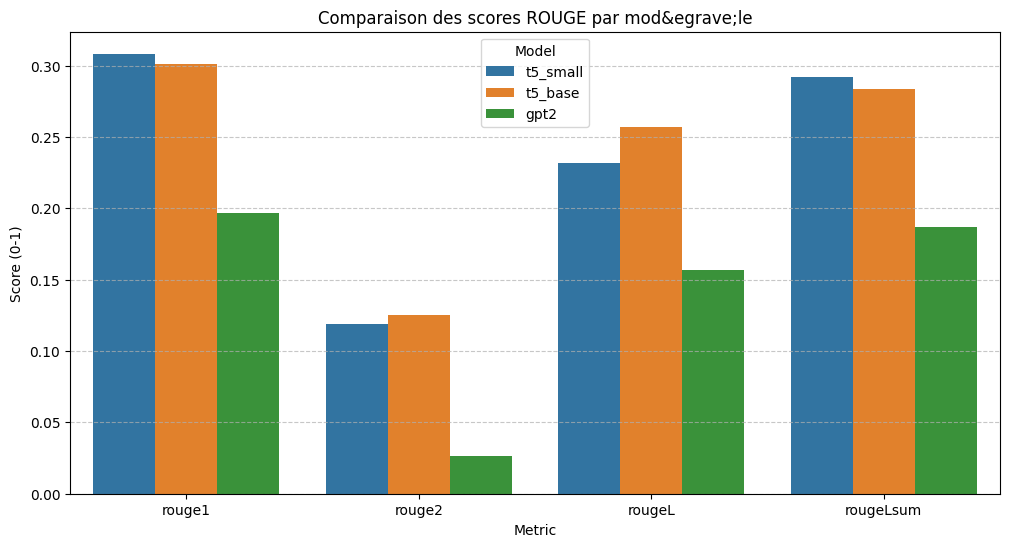

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure comparison_table is calculated here if not already done
if 'sample_test' in globals() and 'comparison_table' not in globals():
    comparison_table = compare_models(sample_test, ['t5_small', 't5_base', 'gpt2'])

if 'comparison_table' in globals():
    # Pr&eacute;paration des donn&eacute;es pour le graphique
    plot_data = comparison_table.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
    plot_data.columns = ['Model', 'Metric', 'Score']

    plt.figure(figsize=(12, 6))
    sns.barplot(data=plot_data, x='Metric', y='Score', hue='Model')
    plt.title("Comparaison des scores ROUGE par mod&egrave;le")
    plt.ylabel("Score (0-1)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Error: comparison_table missing. Run Part VII and VIII.")

## Partie X — Analyse Finale

### R&eacute;ponses aux questions d'&eacute;valuation

1. **Pr&eacute;cision vs Synth&egrave;se** : La pr&eacute;cision exacte est une mauvaise m&eacute;trique car elle ne tol&egrave;re aucune variation stylistique ou synonymique, m&ecirc;me si le sens est parfait.
2. **Pourquoi ROUGE ?** : C'est le standard car il corr&egrave;le mieux avec le jugement humain en mesurant le rappel des informations cl&eacute;s (n-grammes) pr&eacute;sentes dans la r&eacute;f&eacute;rence.
3. **ROUGE-1, 2, L** :
   - **ROUGE-1** : Unigrammes (vocabulaire).
   - **ROUGE-2** : Bigrammes (fluidit&eacute; locale).
   - **ROUGE-L** : Structure globale (plus longue s&eacute;quence commune).
4. **Taille des mod&egrave;les** : Un mod&egrave;le plus grand (T5-base) offre souvent une meilleure syntaxe, mais si le mod&egrave;le n'est pas sp&eacute;cialis&eacute; (comme GPT-2 sans fine-tuning), ses scores peuvent &ecirc;tre inf&eacute;rieurs &agrave; un petit mod&egrave;le d&eacute;di&eacute; (T5-small).
5. **Limites** : ROUGE ne mesure pas la factualit&eacute; (un mod&egrave;le peut inventer des faits avec des mots de la r&eacute;f&eacute;rence et avoir un bon score). Des m&eacute;triques comme **BERTScore** ou **METEOR** sont des alternatives modernes int&eacute;ressantes.

In [11]:
def compare_models(df, model_cols):
    results = {}
    for col in model_cols:
        scores = compute_rouge_score(df[col].tolist(), df['prompt_title'].tolist())
        results[col] = scores
    return pd.DataFrame(results).T

# Ensure sample_test exists
if 'sample_test' in globals():
    comparison_table = compare_models(sample_test, ['t5_small', 't5_base', 'gpt2'])
    print("--- Comparaison des Scores ROUGE Moyens ---")
    display(comparison_table)
    print("\n--- Comparaison Qualitative (Exemple) ---")
    display(sample_test[['prompt_title', 't5_small', 't5_base', 'gpt2']].head(5))
else:
    print("Error: sample_test not found. Please run Part VII first.")

Error: sample_test not found. Please run Part VII first.


### Conclusion du Projet

Nous avons parcouru l'intégralité du pipeline d'évaluation des LLM pour la synthèse :
1. **Extraction de données** via Hugging Face.
2. **Inférence par lots** optimisée pour le GPU.
3. **Évaluation comparative** entre modèles d'architectures différentes (Encoder-Decoder vs Decoder-only).
4. **Analyse de sensibilité** des métriques ROUGE.

Ce flux de travail constitue une base solide pour tout projet de NLP visant à déployer des modèles de génération de texte en production.

---
**Fin du Notebook**

In [ ]:

# Part I. Setup (run once per runtime)
# Install minimal deps; keep quiet to reduce noise.
!pip -q install rouge_score==0.1.2 evaluate datasets transformers accelerate nltk --quiet

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')



### Part II. Dataset loading and exploration
Preferred dataset: [abisee/cnn_dailymail](https://huggingface.co/datasets/abisee/cnn_dailymail) (map `article` -> `prompt_text`, `highlights` -> `prompt_title`).
- If you have local train/test CSVs with `prompt_text` / `prompt_title`, set the paths below.
- Otherwise, we will auto-sample a small slice from the HF dataset to keep things light.
- Show a couple of rows for a sanity check.
If HF download fails, a tiny fallback sample is used.


In [ ]:

import pandas as pd
from datasets import load_dataset

# Point to your data; leave empty to use the HF cnn_dailymail sample or fallback
train_path = ''  # e.g., '/content/train.csv'
test_path = ''   # e.g., '/content/test.csv'

fallback = pd.DataFrame([
    {
        'prompt_text': 'The cat sat on the mat and purred loudly while the sun set.',
        'prompt_title': 'Cat rests on mat at sunset'
    },
    {
        'prompt_text': 'Scientists discovered water on the moon, opening new research paths.',
        'prompt_title': 'Water found on the moon'
    },
    {
        'prompt_text': 'The local team won the championship after a dramatic final match.',
        'prompt_title': 'Local team clinches title'
    },
])

def load_and_sample(path, split_name, n):
    if path:
        df = pd.read_csv(path)
    else:
        try:
            hf_split = f"{split_name}[:{max(n, 3)}]"
            ds = load_dataset('abisee/cnn_dailymail', '3.0.0', split=hf_split)
            df = ds.to_pandas()[['article', 'highlights']].rename(columns={'article': 'prompt_text', 'highlights': 'prompt_title'})
        except Exception as exc:
            print(f"HF load failed ({exc}); using tiny fallback sample.")
            df = fallback.copy()
    return df.sample(min(n, len(df)), random_state=42).reset_index(drop=True)

train_df = load_and_sample(train_path, 'train', 100)
test_df = load_and_sample(test_path, 'test', 50)

display(train_df.head(2))



### Part III. Summarization with T5 (implement)
Tasks:
- Write `batch_generator` to yield mini-batches.
- Write `summarize_with_t5` using `t5-small` (or swap sizes) with GPU if available.
- Prefix inputs with "summarize: " and decode with `skip_special_tokens=True`.
- Clear CUDA cache between batches (`torch.cuda.empty_cache()`) and gc.collect().


In [ ]:

import torch, gc
from transformers import AutoTokenizer, T5ForConditionalGeneration
from typing import Iterable, List

def batch_generator(items: List[str], batch_size: int):
    # TODO: yield slices of items of length batch_size
    raise NotImplementedError("Implement batch_generator")

def summarize_with_t5(texts: List[str], model_name: str = 't5-small', batch_size: int = 4, max_new_tokens: int = 32):
    # TODO: load tokenizer/model, send to device
    # TODO: tokenize with prefix, generate, decode
    # TODO: clear caches between batches
    raise NotImplementedError("Implement summarize_with_t5")

# RUN_FLAG keeps heavy generation optional for quick debugging
RUN_T5 = False
if RUN_T5:
    train_summaries_t5 = summarize_with_t5(train_df['prompt_text'].tolist(), model_name='t5-small', batch_size=2)
    display(pd.DataFrame({
        'prompt_text': train_df['prompt_text'],
        'reference_summary': train_df['prompt_title'],
        't5_small_summary': train_summaries_t5
    }).head())
else:
    print("Skipping T5 generation for speed. Set RUN_T5=True to execute.")



### Part IV. Accuracy evaluation (toy, likely near zero)
Implement a naive accuracy that checks exact string match between generated and reference summaries.
Discuss why this is harsh for free-form text (almost always zero).


In [ ]:

from typing import List

def compute_accuracy(preds: List[str], refs: List[str]) -> float:
    matches = sum(1 for p, r in zip(preds, refs) if p.strip() == r.strip())
    return matches / max(len(refs), 1)

if 'train_summaries_t5' in locals():
    acc = compute_accuracy(train_summaries_t5, train_df['prompt_title'].tolist())
    print(f"Exact-match accuracy: {acc:.4f}")
else:
    print("Accuracy skipped (no predictions).")



### Part V. ROUGE metric implementation
Use `evaluate.load("rouge")` and NLTK sentence tokenizer.
Preprocess by joining sentences with newlines for better ROUGE-L.


In [ ]:

import evaluate
from nltk.tokenize import sent_tokenize
from typing import List

rouge = evaluate.load('rouge')

def normalize_text(text):
    sents = sent_tokenize(text.strip())
    return "".join(sents)

def compute_rouge_score(preds: List[str], refs: List[str]):
    # TODO: normalize preds/refs; call rouge.compute
    raise NotImplementedError("Implement compute_rouge_score")

# Smoke test with identical strings and empty prediction
test_preds = ["alpha beta", "", "The cat sat."]
test_refs  = ["alpha beta", "reference text", "The cat sat."]
print("ROUGE sanity check (fill function first):")
# print(compute_rouge_score(test_preds, test_refs))



### Part VI. Understanding ROUGE scores
Experiments to run (describe your findings in a text cell):
- Exact match vs. empty prediction.
- Effect of stemming: e.g., "running" vs. "run".
- N-gram overlap: see how ROUGE-1 vs. ROUGE-2 change with partial overlap.
- Symmetry: swap preds/refs and compare.



### Part VII. Comparing small and large models
Goals:
- Generate summaries with `t5-small`, `t5-base`, and `gpt2` (TL;DR style prompt).
- Compute ROUGE for each and store per-row scores.
- Implement `compute_rouge_per_row` to add ROUGE columns to a DataFrame.
- Implement `summarize_with_gpt2` with a TL;DR: prefix and max length guard.
Use small batches and low `max_new_tokens` to keep things snappy.


In [ ]:

from transformers import AutoModelForCausalLM, AutoTokenizer

def summarize_with_gpt2(texts: List[str], model_name: str = 'gpt2', batch_size: int = 2, max_new_tokens: int = 32):
    # TODO: implement simple TL;DR generation (careful with max length)
    raise NotImplementedError("Implement summarize_with_gpt2")

def compute_rouge_per_row(df: pd.DataFrame, pred_col: str, ref_col: str = 'prompt_title'):
    # TODO: for each row, compute ROUGE-L (or ROUGE-1/2) and store results
    raise NotImplementedError("Implement compute_rouge_per_row")

RUN_COMPARE = False
if RUN_COMPARE and 'train_summaries_t5' in locals():
    # Add other model outputs then compute per-row ROUGE
    pass



### Part VIII. Comparing all models
Implement:
- `compare_models` to aggregate average ROUGE across models.
- `compare_models_summaries` to show side-by-side summaries.
Present the tables and discuss which model wins and why.


In [ ]:

import pandas as pd

def compare_models(rouge_dict):
    # TODO: take {model_name: rouge_scores_dict} -> DataFrame with averages
    raise NotImplementedError

def compare_models_summaries(df: pd.DataFrame, pred_cols: list):
    # TODO: subset columns for side-by-side viewing
    raise NotImplementedError



## Wrap-up
- Which metrics felt most informative? Why?
- How did model size impact ROUGE and qualitative quality?
- Where did accuracy break down as a metric?
- How would you extend this to human eval or adversarial probes?
Write a short reflection here.
